In [ ]:
# @title Import CSV file
from google.colab import files
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import io
from typing import Callable
#uploaded = files.upload()
#file = pd.read_csv(io.StringIO(uploaded[list(uploaded.keys())[0]].decode('utf-8')))
df = pd.read_csv('https://raw.githubusercontent.com/Tahvia127/s26-geography-of-rights/refs/heads/main/master_scored.csv')
print(f"Columns: {list(df.columns)}")

Columns: ['State', '1.1', '1.2', '1.3', '1.4', '1.5', '1.6', '2.1', '2.2', '2.3', '2.4', '2.5', '3.1', '3.2', '3.3', '3.4', '3.5', '3.6', '4.1', '4.2', '4.3', '4.4', '4.5', '5.1', '5.2', '5.3', '5.4', '5.5', '1.1_n', '1.2_n', '1.3_n', '1.4_n', '1.5_n', '1.6_n', '2.1_n', '2.2_n', '2.3_n', '2.4_n', '2.5_n', '3.1_n', '3.2_n', '3.3_n', '3.4_n', '3.5_n', '3.6_n', '4.1_n', '4.2_n', '4.3_n', '4.4_n', '4.5_n', '5.1_n', '5.2_n', '5.3_n', '5.4_n', '5.5_n', 'Reproductive Rights', 'LGBTQ+ Protections', 'Voting Access', 'Labor Rights', 'Criminal Justice', 'Composite_EqualWeight', 'Composite_PCA', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'Rank_EqualWeight', 'Rank_PCA']


In [ ]:
state_codes : dict[str,str] = {"Alabama" : "AL",
                               "Alaska" : "AK",
                               "Arizona":"AZ",
                               "Arkansas": "AR",
                               "California": "CA",
                               "Colorado" : "CO",
                               "Connecticut": "CT",
                               "Delaware" : "DE",
                               "District of Columbia" : "DC",
                               "Florida" : "FL",
                               "Georgia" : "GA",
                               "Hawaii" : "HI",
                               "Idaho" : "ID",
                               "Illinois" : "IL",
                               "Indiana" : "IN",
                               "Iowa" : "IA",
                               "Kansas" : "KS",
                               "Kentucky" : "KY",
                               "Louisiana" : "LA",
                               "Maine" : "ME",
                               "Maryland" : "MD",
                               "Massachusetts" : "MA",
                               "Michigan" : "MI",
                               "Minnesota" : "MN",
                               "Mississippi" : "MS",
                               "Missouri" : "MO",
                               "Montana" : "MT",
                               "Nebraska" : "NE",
                               "Nevada" : "NV",
                               "New Hampshire" : "NH",
                               "New Jersey" : "NJ",
                               "New Mexico" : "NM",
                               "New York" : "NY",
                               "North Carolina" : "NC",
                               "North Dakota" : "ND",
                               "Ohio" : "OH",
                               "Oklahoma" : "OK",
                               "Oregon" : "OR",
                               "Pennsylvania" : "PA",
                               "Rhode Island" : "RI",
                               "South Carolina" : "SC",
                               "South Dakota" : "SD",
                               "Tennessee" : "TN",
                               "Texas" : "TX",
                               "Utah" : "UT",
                               "Vermont" : "VT",
                               "Virginia" : "VA",
                               "Washington" : "WA",
                               "West Virginia" : "WV",
                               "Wisconsin" : "WI",
                               "Wyoming" : "WY"}
#print(len(state_codes))
top_ten : pd.DataFrame = df.nsmallest(10, ["Rank_PCA"])
top_ten_codes : str = []
for state in top_ten["State"]:
  top_ten_codes.append(state_codes[state])
top_ten.insert(1,"Codes",top_ten_codes)
print(top_ten["Reproductive Rights"])

fig = go.Figure(data=go.Choropleth(
    locations=top_ten['Codes'], # Spatial coordinates
    z = top_ten['Rank_PCA'].astype(int), # Data to be color-coded
    locationmode = 'USA-states', # set of locations match entries in `locations`
    colorscale = 'Reds',
    reversescale = True,
    colorbar_title = "Rank",
))

"""
fig = go.Figure(data=go.Choropleth(
    locations=["DC"],
    z = [100],
    locationmode = "USA-states",
    colorscale = "Reds"
))
"""
fig.update_traces(marker_line_color="Black", selector=dict(type='choropleth'))

fig.update_layout(
    title_text = 'The Top Ten States Most Protective of Human Rights<br>(Reproductive rights, LGBTQ+ Protections, Voting Access, Labor Rights, and Criminal Justice)',
    geo_scope='usa', # limit map scope to USA
)

fig.show()

8      83.333333
4      96.666667
30    100.000000
47     96.666667
5      91.666667
23    100.000000
20     83.333333
37    100.000000
32     96.666667
13     96.666667
Name: Reproductive Rights, dtype: float64


In [ ]:
df.nlargest(1,["Rank_PCA"])

,State,1.1,1.2,1.3,1.4,1.5,1.6,2.1,2.2,2.3,...,P3,P4,P5,P6,P7,P8,P9,P10,Rank_EqualWeight,Rank_PCA
42,Tennessee,0,0,0,0,0,0,-14.0,0,0,...,66.4,70.9,16.7,6.2,0.481,3.3,0,R,51,51


Text(0.5, 1.0, 'Average reproductive rights score\n(across 10 most protective states overall)')

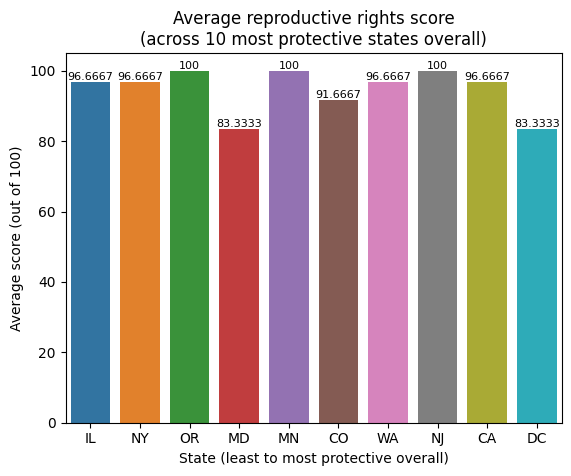

In [ ]:
import seaborn as sns

#least_state = list(df.nsmallest(10,["Reproductive Rights"])["State"])
least_codes = []
#top_ten_codes : str = []
for state in list(df.nsmallest(10,["Rank_PCA"])["State"]):
  least_codes.append(state_codes[state])
least_rr = list(df.nsmallest(10,["Rank_PCA"])["Reproductive Rights"])
least_codes.reverse()
least_rr.reverse()
#print(least_rr)

b = sns.barplot(x=least_codes,y=least_rr,hue=least_codes)
b.set(xlabel = "State (least to most protective overall)")
for i in range(10):
  b.bar_label(b.containers[i],fontsize=8)
b.set(ylabel = "Average score (out of 100)")
b.set_title("Average reproductive rights score\n(across 10 most protective states overall)")
#b.set(ylabel = "")